<a href="https://colab.research.google.com/github/anyaknudsen/quantized-residual-analysis/blob/main/quantized_residual_analysis_draft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantized Residual Distribution Analysis — Draft 2

Fixes relative to draft 1:

1. **Real speech.** Analysis now runs on LibriSpeech `dev-clean` (extracted from the uploaded tarball), not IID Laplace. Laplace is kept only as a sanity-check input.
2. **Conditional entropy fixed.** Draft 1 fed a list of tuples into `np.unique`, which does not count *pairs* as joint symbols — this is why $H(Z_n|Z_{n-1})$ came out $\approx 0$ even for IID input. Joint counts now use integer pair-encoding (`prev * L + curr`) with `np.bincount`.
3. **$Z_n$ convention.** The task prompt writes $Z_n = Q(X_n+V_n) - V_n$, but entropy coding needs a *discrete* alphabet, and the project documentation's compression section defines $Z = Q(X+V)$ and plots PMFs of $y_q = Q(x+v)$ and $d[n] = y_q[n]-y_q[n-1]$. **We therefore analyze the discrete quantizer output** (bin index $k$, equivalently level $C_k$; the two are the same alphabet up to an affine map). The subtractively dithered reconstruction $Q(X_n+V_n)-V_n$ is still computed in the loop for completeness, but it is not the entropy-coded variable: subtracting the continuous dither would destroy the finite alphabet and inject dither differences $V_{n-1}-V_n$ into the residual.
4. **Reconstruction levels.** $C_k = -1 + (k + 0.5)\,\Delta$ for internal index $k \in \{0,\dots,2^b-1\}$, matching the documentation's mid-riser levels ($b{=}1$: $\pm 1/2$; $b{=}2$: $\pm 1/4, \pm 3/4$; $b{=}3$: $\pm 1/8,\dots,\pm 7/8$). Verified explicitly below.
5. **No-overload accounting.** The clipped-sample fraction is reported for every $(b, \alpha)$ instead of silently saturating.
6. **Silence and file boundaries.** Results are reported twice — all samples, and active-speech only (frame-energy VAD). Residuals and conditional-entropy pairs are never formed across file or segment boundaries.
7. **PMF deliverable.** $Z_n$ vs $\Delta Z_n$ PMF comparison is actually plotted, for all of $b \in \{1,2,3\}$.
8. **Sanity checks.** IID Laplace should give $H(Z_n|Z_{n-1}) \approx H(Z_n)$; a constant sequence should give $\approx 0$; speech should land in between.


In [ ]:
!pip install -q librosa soundfile

import os, glob, tarfile
import numpy as np
import matplotlib.pyplot as plt
import librosa

rng_global = np.random.default_rng(0)


## Data: LibriSpeech dev-clean

Upload `dev-clean.tar.gz` (or skip the upload cell if it is already in the working directory). We extract the first `NUM_FILES` FLAC files, load at 16 kHz, and peak-normalize each utterance to $0.95$ so the input sits inside the quantizer support $[-1, 1)$ with headroom for dither. Overload events are counted, not hidden.

In [ ]:
TARBALL = "dev-clean.tar.gz"

if not os.path.exists(TARBALL):
    from google.colab import files
    uploaded = files.upload()  # upload dev-clean.tar.gz

NUM_FILES = 10  # ~1 minute of speech total; enough for stable PMFs at b<=3

if not glob.glob("librispeech/**/*.flac", recursive=True):
    with tarfile.open(TARBALL) as tar:
        members = [m for m in tar.getmembers() if m.name.endswith(".flac")][:NUM_FILES]
        tar.extractall(path="librispeech", members=members)

flac_files = sorted(glob.glob("librispeech/**/*.flac", recursive=True))[:NUM_FILES]
print(f"Loaded file list ({len(flac_files)} files):")

signals = []
for f in flac_files:
    x, sr = librosa.load(f, sr=16000)
    x = 0.95 * x / np.max(np.abs(x))   # peak-normalize with headroom
    signals.append(x.astype(np.float64))
    print(f"  {os.path.basename(f)}  {len(x)/sr:.1f}s")

total_sec = sum(len(x) for x in signals) / 16000
print(f"Total speech: {total_sec:.1f} s")


Saving dev-clean.tar.gz to dev-clean.tar.gz


/tmp/ipykernel_14122/2503125127.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="librispeech", members=members)


Loaded file list (10 files):
  2277-149896-0005.flac  5.6s
  2277-149896-0006.flac  5.0s
  2277-149896-0012.flac  2.5s
  2277-149896-0015.flac  3.7s
  2277-149896-0018.flac  4.5s
  2277-149896-0021.flac  3.4s
  2277-149896-0026.flac  4.9s
  2277-149896-0027.flac  3.6s
  2277-149896-0033.flac  2.8s
  2277-149896-0034.flac  4.0s
Total speech: 40.0 s


## Dithered quantizer

Dither model per the project documentation: $f_V(v) = \alpha\,\Pi_{\alpha\Delta}(v) + (1-\alpha)\,\delta(v)$, i.e. with probability $1-\alpha$, $V = 0$; with probability $\alpha$, $V \sim \mathrm{Uniform}[-\alpha\Delta/2,\ \alpha\Delta/2]$.

Mid-riser quantizer with $\Delta = 2/2^b$, thresholds $T_k$, levels $C_k = -1 + (k+0.5)\Delta$ for $k = 0,\dots,2^b-1$.

In [ ]:
def generate_dither(n, alpha, Delta, rng):
    v = np.zeros(n)
    if alpha == 0:
        return v
    mask = rng.random(n) < alpha
    v[mask] = rng.uniform(-alpha * Delta / 2, alpha * Delta / 2, size=mask.sum())
    return v


def mid_riser_quantizer(y, b):
    '''Returns (k, C, clip_fraction). k in {0,...,2^b - 1}; C_k = -1 + (k+0.5)*Delta.'''
    L = 2 ** b
    Delta = 2 / L
    clipped = (y < -1) | (y >= 1)
    y_c = np.clip(y, -1, 1 - 1e-12)
    k = np.floor((y_c + 1) / Delta).astype(int)
    C = -1 + (k + 0.5) * Delta
    return k, C, clipped.mean()


def quantization_loop(x, b, alpha, rng):
    '''Quantize one contiguous segment. Z := k (discrete quantizer output symbol).
    z_recon = C - v is the subtractive reconstruction (waveform-domain, NOT entropy-coded).'''
    L = 2 ** b
    Delta = 2 / L
    v = generate_dither(len(x), alpha, Delta, rng)
    k, C, clip_frac = mid_riser_quantizer(x + v, b)
    z_recon = C - v
    return k, C, z_recon, clip_frac


# Verify levels against the project documentation
for b in [1, 2, 3]:
    L = 2 ** b
    ks = np.arange(L)
    C = -1 + (ks + 0.5) * (2 / L)
    print(f"b={b}: C_k = {C}")


b=1: C_k = [-0.5  0.5]
b=2: C_k = [-0.75 -0.25  0.25  0.75]
b=3: C_k = [-0.875 -0.625 -0.375 -0.125  0.125  0.375  0.625  0.875]


## Entropy machinery (fixed)

$H(Z_n|Z_{n-1}) = H(Z_n, Z_{n-1}) - H(Z_{n-1})$, with the joint estimated over **ordered pairs** via integer pair-encoding. All pairs are formed strictly within contiguous segments — never across file or VAD-segment boundaries.

Note the project documentation's displayed conditional-entropy formula appears to have a typo ($p(z_n = z_{n-1})$ inside the sum); the correct expression sums $-p(z_n, z_{n-1}) \log_2 \frac{p(z_n, z_{n-1})}{p(z_{n-1})}$ over all ordered pairs, which is what is implemented here.

In [ ]:
def _entropy_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if total == 0:
        return 0.0
    p = counts[counts > 0] / total
    return float(-np.sum(p * np.log2(p)))


def marginal_entropy(symbols):
    _, counts = np.unique(symbols, return_counts=True)
    return _entropy_from_counts(counts)


def conditional_entropy(symbol_segments, L):
    '''H(Z_n | Z_{n-1}) over a list of contiguous integer-symbol segments (each in 0..L-1).'''
    joint = np.zeros(L * L)
    prev_counts = np.zeros(L)
    for seg in symbol_segments:
        if len(seg) < 2:
            continue
        prev, curr = seg[:-1], seg[1:]
        joint += np.bincount(prev * L + curr, minlength=L * L)
        prev_counts += np.bincount(prev, minlength=L)
    return _entropy_from_counts(joint) - _entropy_from_counts(prev_counts)


def residuals(symbol_segments):
    '''Concatenated first-order residuals dZ, computed within segments only.'''
    ds = [seg[1:] - seg[:-1] for seg in symbol_segments if len(seg) >= 2]
    return np.concatenate(ds) if ds else np.array([], dtype=int)


## Sanity checks

* IID Laplace input $\Rightarrow$ $H(Z_n|Z_{n-1}) \approx H(Z_n)$ (no temporal structure to exploit).
* Constant input $\Rightarrow$ $H(Z_n|Z_{n-1}) \approx 0$.
* Real speech should fall strictly between.

Draft 1 failed the first check ($H(Z_n|Z_{n-1}) \equiv 0$ for IID input) because of the joint-counting bug.

In [ ]:
rng = np.random.default_rng(1)
b_test, alpha_test = 2, 0.5
L_test = 2 ** b_test

# IID Laplace
x_iid = np.clip(rng.laplace(0, 0.3, 200_000), -1, 1 - 1e-12)
k_iid, *_ = quantization_loop(x_iid, b_test, alpha_test, rng)
H_iid, Hc_iid = marginal_entropy(k_iid), conditional_entropy([k_iid], L_test)
print(f"IID Laplace : H(Z)={H_iid:.4f}  H(Z|Z-1)={Hc_iid:.4f}  (should be nearly equal)")
assert abs(H_iid - Hc_iid) < 0.02, "IID sanity check failed"

# Constant input
x_const = np.full(200_000, 0.1)
k_const, *_ = quantization_loop(x_const, b_test, 0.0, rng)
Hc_const = conditional_entropy([k_const], L_test)
print(f"Constant    : H(Z|Z-1)={Hc_const:.4f}  (should be ~0)")
assert Hc_const < 1e-6, "Constant sanity check failed"

print("Sanity checks passed.")


IID Laplace : H(Z)=1.7029  H(Z|Z-1)=1.7029  (should be nearly equal)
Constant    : H(Z|Z-1)=0.0000  (should be ~0)
Sanity checks passed.


## Silence handling

Speech is quasi-WSS on short frames, and silence produces long runs of identical symbols that inflate $P(\Delta Z_n = 0)$ for reasons unrelated to speech dynamics. We therefore report two conditions:

* **All samples** — reflects the full transmission distribution (what a deployed codec actually sees, silence included).
* **Active speech** — 25 ms frame-energy VAD at $-40$ dB relative to the peak-RMS frame; isolates temporal correlation of active speech. Each contiguous active run is treated as its own segment, so no residual pair straddles a removed gap.

In [ ]:
def active_speech_segments(x, sr=16000, frame_ms=25, thresh_db=-40):
    '''Split x into contiguous active-speech segments via frame-energy threshold.'''
    flen = int(sr * frame_ms / 1000)
    n_frames = len(x) // flen
    if n_frames == 0:
        return []
    frames = x[: n_frames * flen].reshape(n_frames, flen)
    rms = np.sqrt(np.mean(frames ** 2, axis=1))
    active = rms > rms.max() * 10 ** (thresh_db / 20)
    mask = np.zeros(len(x), dtype=bool)
    mask[: n_frames * flen] = np.repeat(active, flen)
    edges = np.flatnonzero(np.diff(np.concatenate(([0], mask.view(np.int8), [0]))))
    return [x[a:b] for a, b in zip(edges[::2], edges[1::2])]


segments_all = list(signals)  # one segment per file (no cross-file pairs)
segments_active = [seg for x in signals for seg in active_speech_segments(x)]

n_all = sum(len(s) for s in segments_all)
n_act = sum(len(s) for s in segments_active)
print(f"All samples: {n_all}   Active-speech samples: {n_act} ({100*n_act/n_all:.1f}%)")


All samples: 640320   Active-speech samples: 550000 (85.9%)


## Deliverable 3 — PMF of $Z_n$ vs $\Delta Z_n$

Quantizer-output PMF (plotted over levels $C_k$) versus the first-order residual PMF (in units of $\Delta$), for $b \in \{1,2,3\}$, matching the project documentation's Figs. 18–20. The claim to verify: $\Delta Z_n$ concentrates far more mass at zero than $Z_n$ puts on any single state.

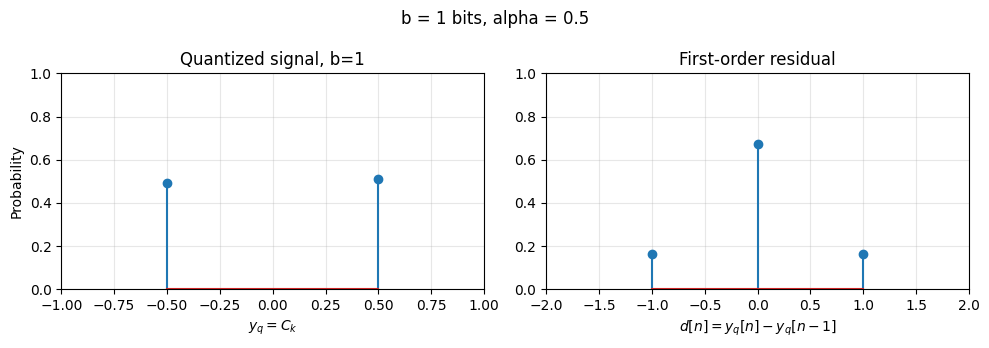

b=1: P(dZ=0) = 0.6724   max_k P(Z=k) = 0.5091   P(Z_n = Z_(n-1)) = 0.6724


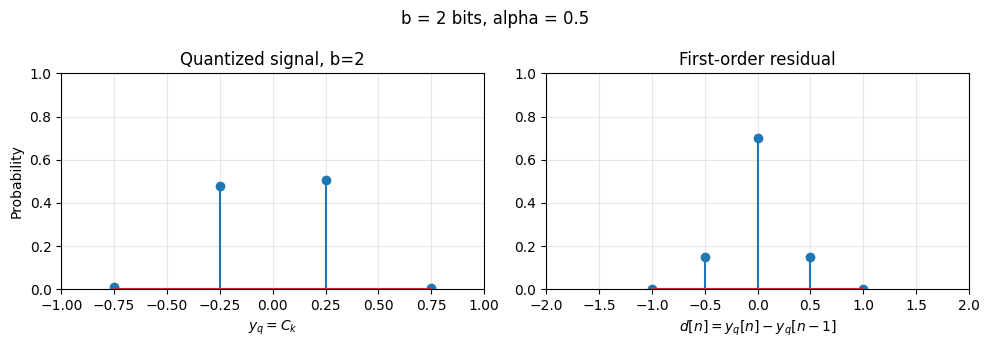

b=2: P(dZ=0) = 0.7022   max_k P(Z=k) = 0.5044   P(Z_n = Z_(n-1)) = 0.7022


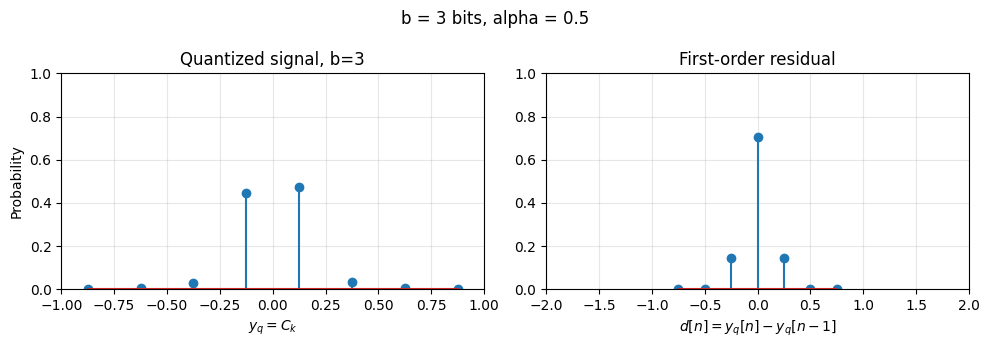

b=3: P(dZ=0) = 0.7076   max_k P(Z=k) = 0.4723   P(Z_n = Z_(n-1)) = 0.7076


In [ ]:
alpha_demo = 0.5
rng = np.random.default_rng(2)

for b in [1, 2, 3]:
    L = 2 ** b
    Delta = 2 / L
    sym_segs = [quantization_loop(seg, b, alpha_demo, rng)[0] for seg in segments_all]
    Z_all = np.concatenate(sym_segs)
    dZ = residuals(sym_segs)

    states_Z, cnt_Z = np.unique(Z_all, return_counts=True)
    states_d, cnt_d = np.unique(dZ, return_counts=True)
    pmf_Z, pmf_d = cnt_Z / cnt_Z.sum(), cnt_d / cnt_d.sum()

    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    ax[0].stem(-1 + (states_Z + 0.5) * Delta, pmf_Z)
    ax[0].set(title=f"Quantized signal, b={b}", xlabel=r"$y_q = C_k$",
              ylabel="Probability", xlim=(-1, 1), ylim=(0, 1))
    ax[1].stem(states_d * Delta, pmf_d)
    ax[1].set(title="First-order residual", xlabel=r"$d[n]=y_q[n]-y_q[n-1]$",
              xlim=(-2, 2), ylim=(0, 1))
    for a in ax:
        a.grid(alpha=0.3)
    fig.suptitle(f"b = {b} bits, alpha = {alpha_demo}")
    plt.tight_layout()
    plt.show()

    print(f"b={b}: P(dZ=0) = {np.mean(dZ == 0):.4f}   "
          f"max_k P(Z=k) = {pmf_Z.max():.4f}   "
          f"P(Z_n = Z_(n-1)) = {np.mean(dZ == 0):.4f}")


## Deliverable 4 — $H(Z_n)$ and $H(Z_n|Z_{n-1})$ vs $\alpha$

For each $b \in \{1,2,3\}$ we sweep $\alpha \in [0,1]$ and report, for both all-samples and active-speech conditions:

* $H(Z_n)$ — marginal entropy of the quantizer output,
* $H(Z_n|Z_{n-1})$ — conditional entropy, the fundamental limit for a first-order encoding scheme,
* clipped-sample fraction (no-overload accounting).

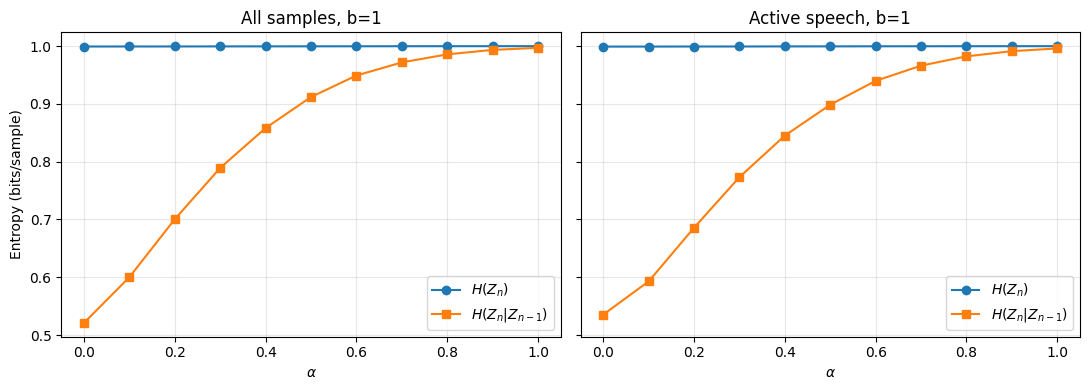

b=1 clipped fraction across alpha (all samples): 0.0:0.00e+00, 0.1:0.00e+00, 0.2:2.34e-05, 0.3:5.15e-05, 0.4:1.42e-04, 0.5:2.89e-04, 0.6:4.69e-04, 0.7:6.50e-04, 0.8:1.03e-03, 0.9:1.52e-03, 1.0:2.33e-03
b=1 P(dZ=0) at alpha=0 / 0.5 / 1 (all): 0.883 / 0.673 / 0.532
b=1 P(dZ=0) at alpha=0 / 0.5 / 1 (active): 0.878 / 0.685 / 0.537



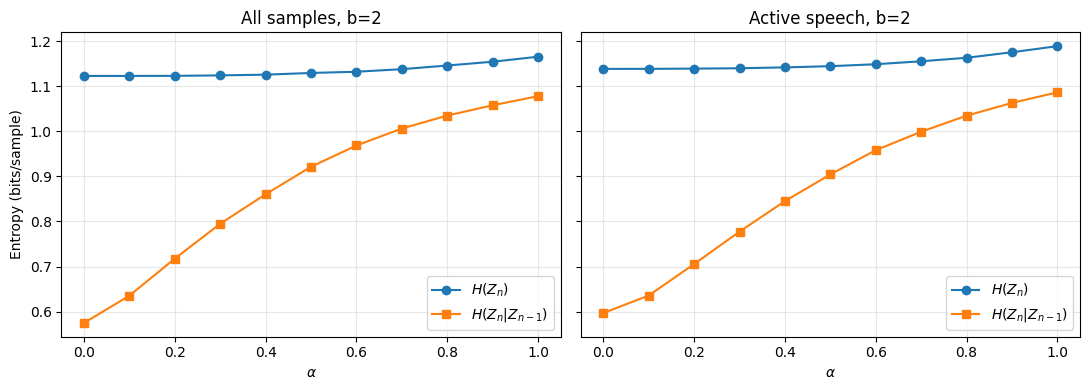

b=2 clipped fraction across alpha (all samples): 0.0:0.00e+00, 0.1:0.00e+00, 0.2:0.00e+00, 0.3:1.09e-05, 0.4:3.44e-05, 0.5:8.75e-05, 0.6:1.36e-04, 0.7:2.08e-04, 0.8:3.06e-04, 0.9:4.33e-04, 1.0:5.42e-04
b=2 P(dZ=0) at alpha=0 / 0.5 / 1 (all): 0.873 / 0.702 / 0.551
b=2 P(dZ=0) at alpha=0 / 0.5 / 1 (active): 0.867 / 0.718 / 0.558



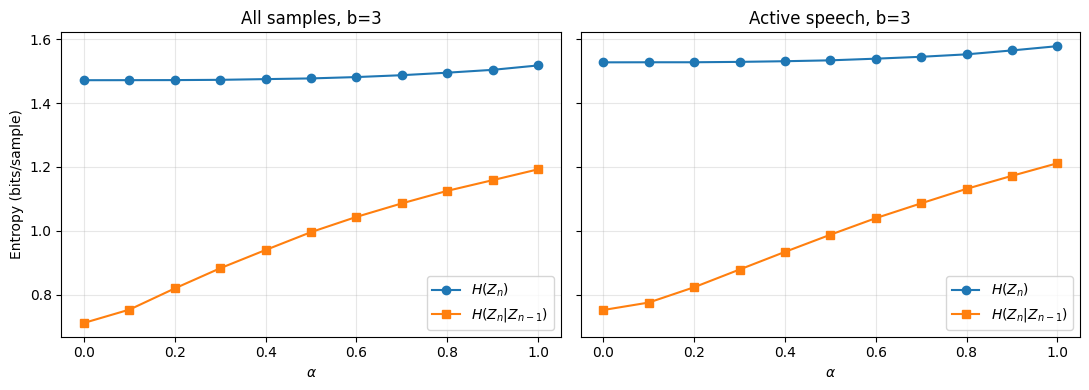

b=3 clipped fraction across alpha (all samples): 0.0:0.00e+00, 0.1:0.00e+00, 0.2:0.00e+00, 0.3:0.00e+00, 0.4:0.00e+00, 0.5:1.09e-05, 0.6:3.12e-05, 0.7:5.93e-05, 0.8:8.59e-05, 0.9:1.30e-04, 1.0:1.66e-04
b=3 P(dZ=0) at alpha=0 / 0.5 / 1 (all): 0.843 / 0.706 / 0.562
b=3 P(dZ=0) at alpha=0 / 0.5 / 1 (active): 0.832 / 0.722 / 0.572



In [ ]:
def sweep_alpha(segments, b, alphas, seed=3):
    rng = np.random.default_rng(seed)
    L = 2 ** b
    out = {"H_Z": [], "H_cond": [], "p0": [], "clip": []}
    n_total = sum(len(s) for s in segments)
    for alpha in alphas:
        sym_segs, clip_weighted = [], 0.0
        for seg in segments:
            k, _, _, cf = quantization_loop(seg, b, alpha, rng)
            sym_segs.append(k)
            clip_weighted += cf * len(seg)
        Z_all = np.concatenate(sym_segs)
        dZ = residuals(sym_segs)
        out["H_Z"].append(marginal_entropy(Z_all))
        out["H_cond"].append(conditional_entropy(sym_segs, L))
        out["p0"].append(np.mean(dZ == 0))
        out["clip"].append(clip_weighted / n_total)
    return {k: np.array(v) for k, v in out.items()}


alphas = np.linspace(0, 1, 11)

for b in [1, 2, 3]:
    res_all = sweep_alpha(segments_all, b, alphas)
    res_act = sweep_alpha(segments_active, b, alphas)

    fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for a, res, name in [(ax[0], res_all, "All samples"),
                         (ax[1], res_act, "Active speech")]:
        a.plot(alphas, res["H_Z"], "o-", label=r"$H(Z_n)$")
        a.plot(alphas, res["H_cond"], "s-", label=r"$H(Z_n|Z_{n-1})$")
        a.set(title=f"{name}, b={b}", xlabel=r"$\alpha$")
        a.grid(alpha=0.3)
        a.legend()
    ax[0].set_ylabel("Entropy (bits/sample)")
    plt.tight_layout()
    plt.show()

    print(f"b={b} clipped fraction across alpha (all samples): "
          + ", ".join(f"{a:.1f}:{c:.2e}" for a, c in zip(alphas, res_all["clip"])))
    print(f"b={b} P(dZ=0) at alpha=0 / 0.5 / 1 (all): "
          f"{res_all['p0'][0]:.3f} / {res_all['p0'][5]:.3f} / {res_all['p0'][10]:.3f}")
    print(f"b={b} P(dZ=0) at alpha=0 / 0.5 / 1 (active): "
          f"{res_act['p0'][0]:.3f} / {res_act['p0'][5]:.3f} / {res_act['p0'][10]:.3f}\n")


## Discussion

**Claims, stated separately:**

1. **Temporal dependence exists in the quantized output.** $P(Z_n = Z_{n-1})$ is large for real speech at low bit depth, in both silence-included and active-speech conditions (though it is inflated by silence, which is why both are reported).
2. **The residual PMF is more peaked than the state PMF.** $\Delta Z_n$ concentrates most of its mass at $0$, while $Z_n$ spreads mass across levels — the precondition for Huffman/arithmetic coding gains via differential encoding.
3. **$H(Z_n|Z_{n-1}) < H(Z_n)$ for real speech**, and the gap is the compressible temporal redundancy. For IID input the gap vanishes (sanity check), for constant input the conditional entropy vanishes.
4. **$\alpha$ trades compression against distortion behavior.** Dither whitens quantization error and reduces harmonic distortion (the MSE/MACE/MSCO analyses in the project documentation all improve as $\alpha \uparrow$), but it *decorrelates the quantized output*, so $H(Z_n|Z_{n-1})$ **increases** with $\alpha$. For pure compression efficiency, $\alpha = 0$ or small $\alpha$ is best; for ASR robustness / distortion whitening, larger $\alpha$ is better. The choice of $\alpha$ is a rate–robustness tradeoff, not a free win.

**Coding-scheme note.** A first-order context coder on $Z_n$ conditioned on $Z_{n-1}$ achieves rate $\approx H(Z_n|Z_{n-1})$ — this is the fundamental limit plotted in Deliverable 4. A simpler memoryless coder on the residuals $\Delta Z_n$ achieves a rate no better than this limit; the residual PMFs in Deliverable 3 are the evidence of the temporal predictability that either scheme exploits.

**Open questions for the instructor:** whether the graded deliverable should treat $Z_n$ per the task prompt ($Q(X+V)-V$) or per the project documentation's compression section ($Q(X+V)$, used here); and whether the final metric of interest is compression rate or ASR-preserving quantization.